In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 10]
%matplotlib inline


In [3]:
# Read data
df1 = pd.read_csv('../datasets/TX-Data/met_station/met_1.dat', sep=",", parse_dates=["Date"], index_col="Date")
df2 = pd.read_csv('../datasets/TX-Data/met_station/met_2.dat', sep=",", parse_dates=["Date"], index_col="Date")
df3 = pd.read_csv('../datasets/TX-Data/met_station/met_3.dat', sep=",", parse_dates=["Date"], index_col="Date")
df4 = pd.read_csv('../datasets/TX-Data/met_station/met_4.dat', sep=",", parse_dates=["Date"], index_col="Date")
df5 = pd.read_csv('../datasets/TX-Data/met_station/met_5.dat', sep=",", parse_dates=["Date"], index_col="Date")
df6 = pd.read_csv('../datasets/TX-Data/met_station/met_6.dat', sep=",", parse_dates=["Date"], index_col="Date")

In [4]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [5]:

# save dataframes into list
DF = [df1, df2, df3, df4, df5, df6]

# remove column name spaces of each DataFrame 
for df in DF:
    remove_spaces(df)
    
    

In [6]:
# Selects a feature from the data. Creates df with Stations as columns.
# Takes in list of dataframes and the selected feature as a string. 
def select_feature(DF, feature):
    df_feature = pd.concat(DF, axis=1)[feature]
    df_feature.columns = [str(f"Station{i}") for i in range(1, len(DF)+1)]
    return df_feature

In [7]:
# create df with only Air temp data of each Station
df_Tair = select_feature(DF, "Tair")


In [8]:
# Exlude Station 1 and 5 Air Temp data from mean
df_2018_Tair_mean = df_Tair.drop(["Station1", "Station5"], axis=1).mean(axis=1)


In [9]:
# imputes missing values with mean
def mean_imputation (df, df_mean):
    to_impute = df[df.isna() == True].index
    df[to_impute] = df_mean[to_impute]
    
    # document imputed indices
    return to_impute


In [10]:
# replaces values below given limit with mean
def mean_replace_low (df, df_mean, lim):
    to_replace = df[df < lim].index
    df[to_replace] = df_mean[to_replace]
    
    # document replaced indices
    return to_replace

In [11]:
# Clean Data
# Record changed indices
S5_2018_imputed = mean_imputation (df_Tair["2018-4":"2018-5"].Station5, df_2018_Tair_mean)
S5_2018_replaced = mean_replace_low (df_Tair["2018-4":"2018-5"].Station5, df_2018_Tair_mean, -20)

In [12]:
# Clean Data
# Record changed indices
S1_2018_imputed = mean_imputation (df_Tair["2018-4":"2018-8"].Station1, df_2018_Tair_mean)
S1_2018_replaced = mean_replace_low (df_Tair["2018-4":"2018-8"].Station1, df_2018_Tair_mean, -10)


In [13]:
# Exlude Station 1 Air Temp data from mean
df_2019_Tair_mean = df_Tair.drop(["Station1"], axis=1).mean(axis=1)

In [14]:
# Clean Data
# Record changed indices
S1_2019_replaced = mean_replace_low (df_Tair["2019-3":"2019-3"].Station1, df_2019_Tair_mean, -20)


In [15]:
# Exlude Station 2 Air Temp data from mean
df_2021_Tair_mean = df_Tair.drop(["Station2"], axis=1).mean(axis=1)


In [16]:
# Clean Data
# Record changed indices
S2_2021_imputed = mean_imputation (df_Tair["2021-6":"2021-9"].Station2, df_2021_Tair_mean)


In [17]:
# Concatenate and sort changed indices for each Station
S1_changed_idx = (S1_2018_replaced.union(S1_2018_imputed)).union(S1_2019_replaced)
S2_changed_idx = S2_2021_imputed
S5_changed_idx = S5_2018_imputed.union(S5_2018_replaced)

In [18]:
# Exclude data with dates before 2015
reindex_df_Tair = df_Tair[(df_Tair.index >= "2014-12-31 23:00")]

In [19]:
# Fill nan values
reindex_df_Tair.replace([np.inf, -np.inf], np.nan, inplace=True)
reindex_df_Tair.fillna(reindex_df_Tair.mean(), inplace=True)

In [36]:
update_df_Tair = reindex_df_Tair.loc["2015"].resample('M').mean()

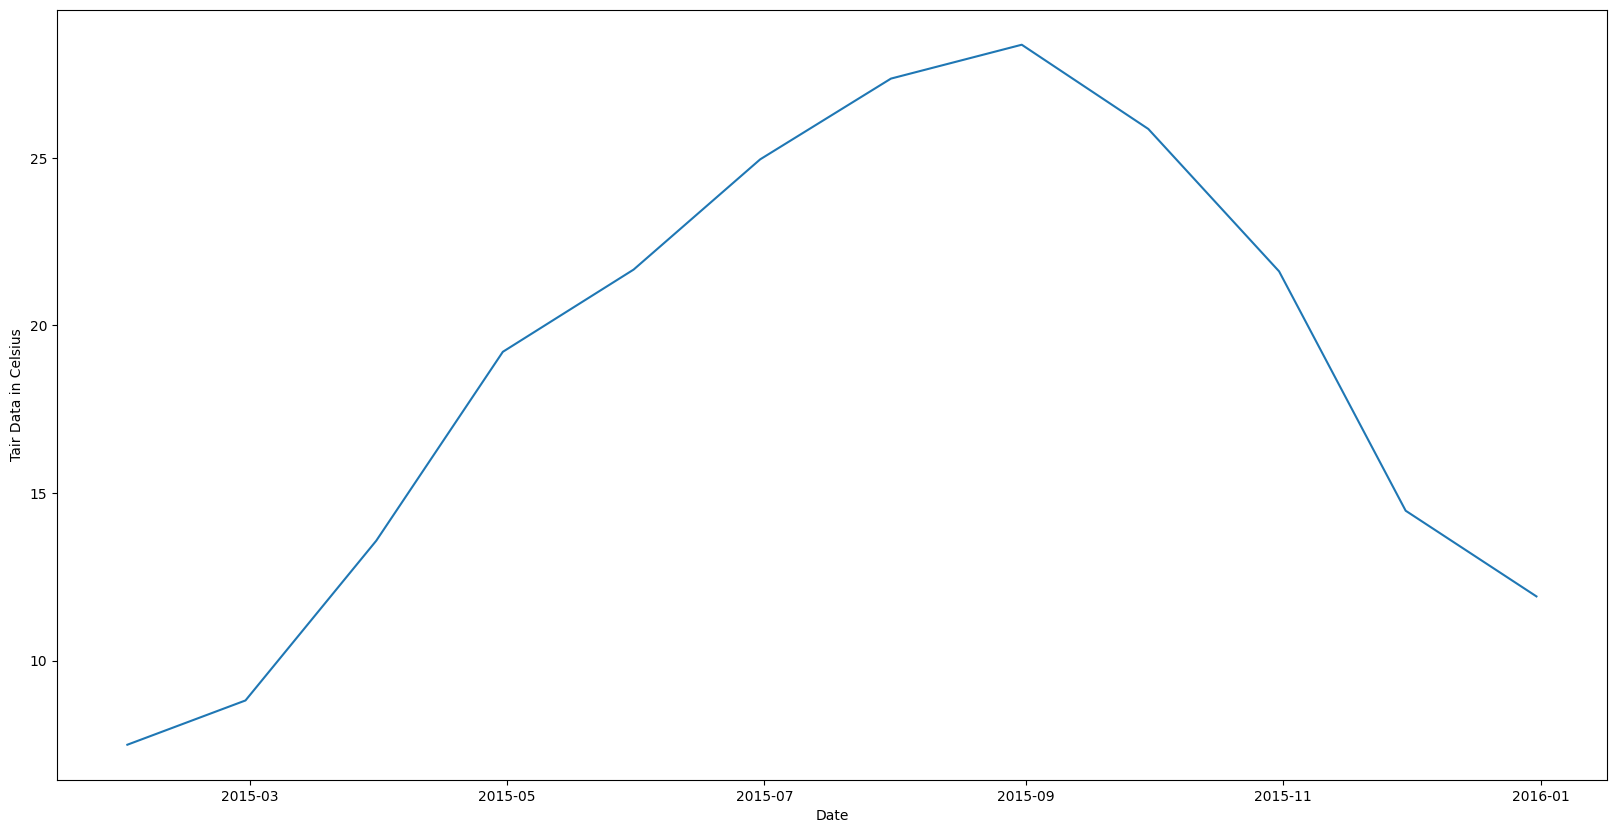

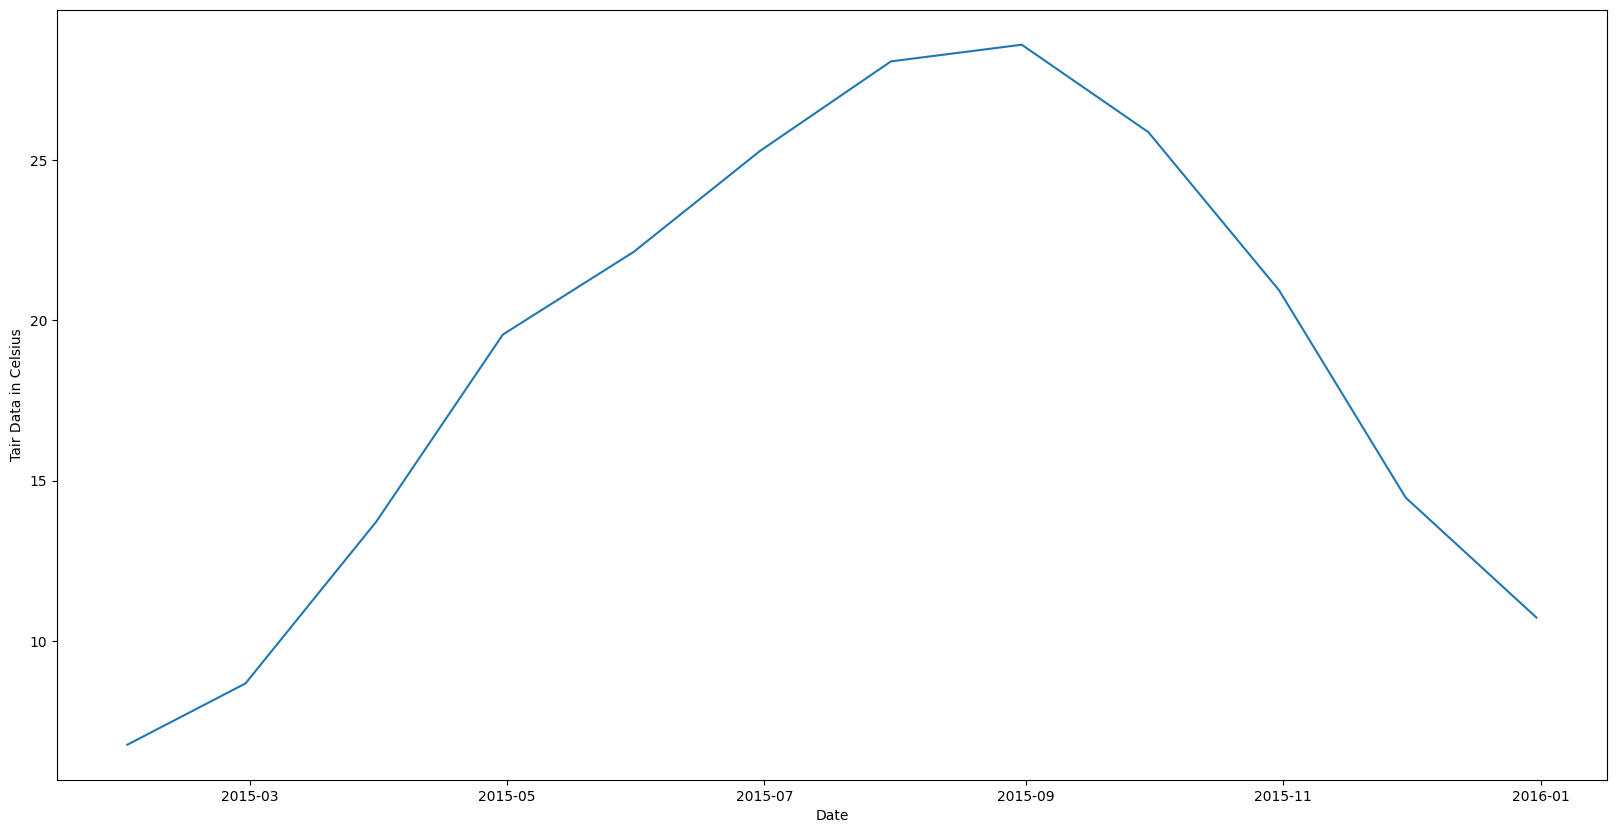

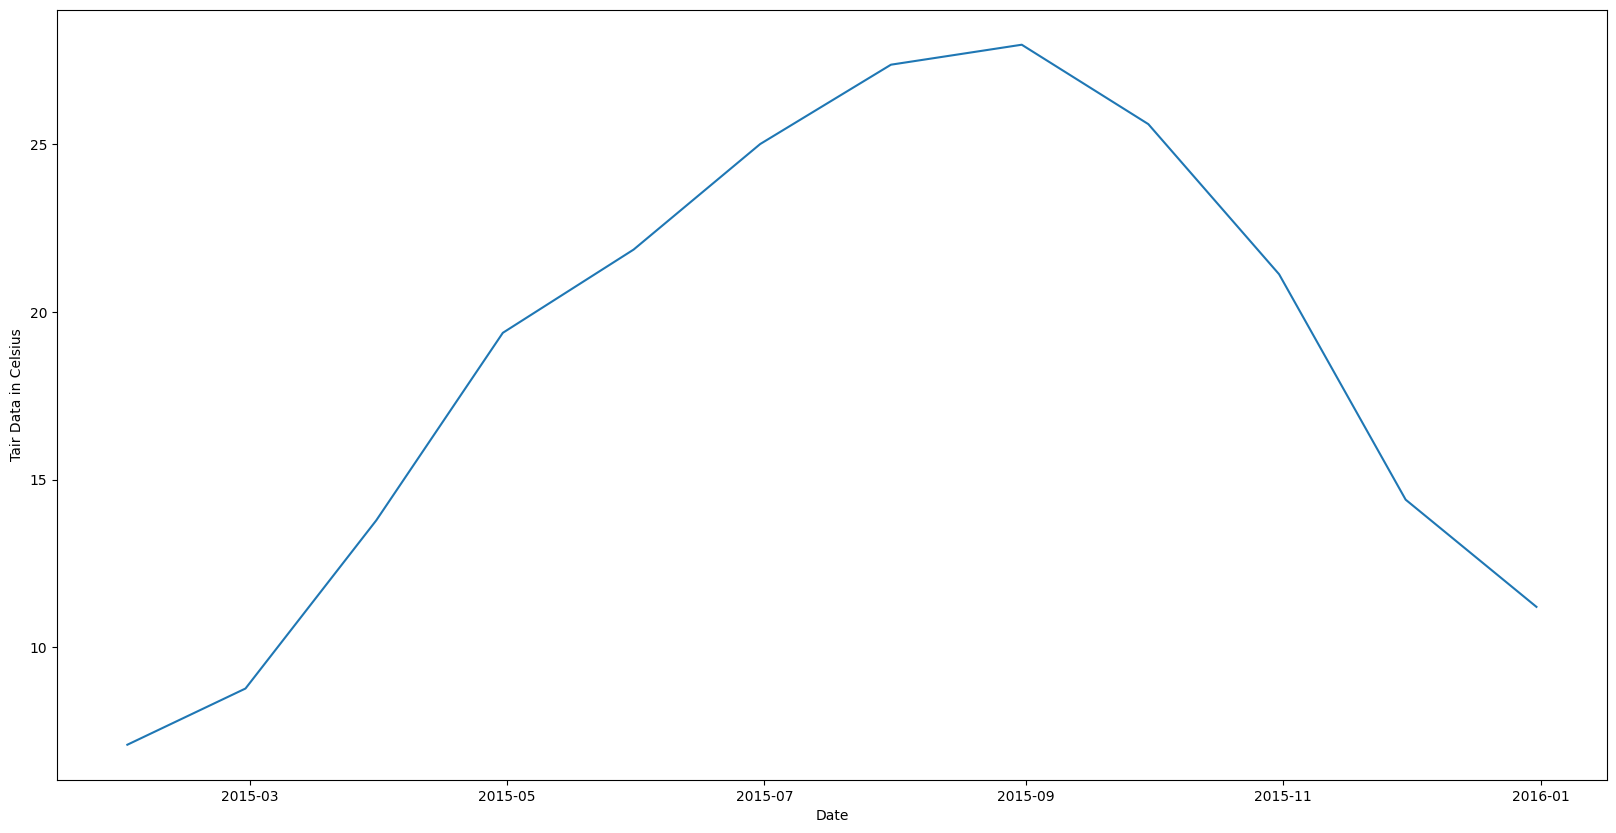

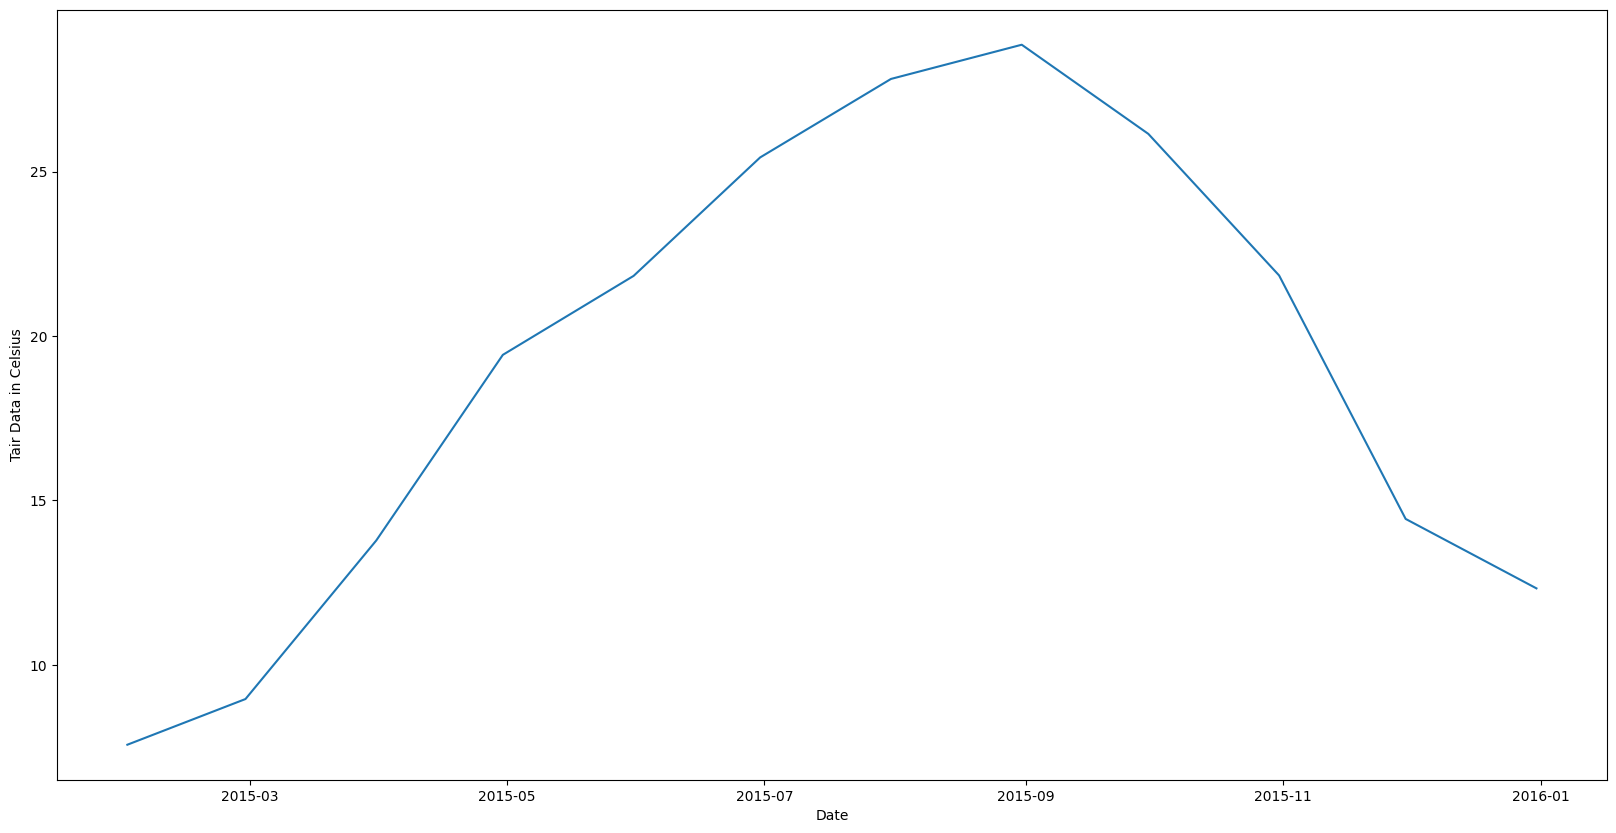

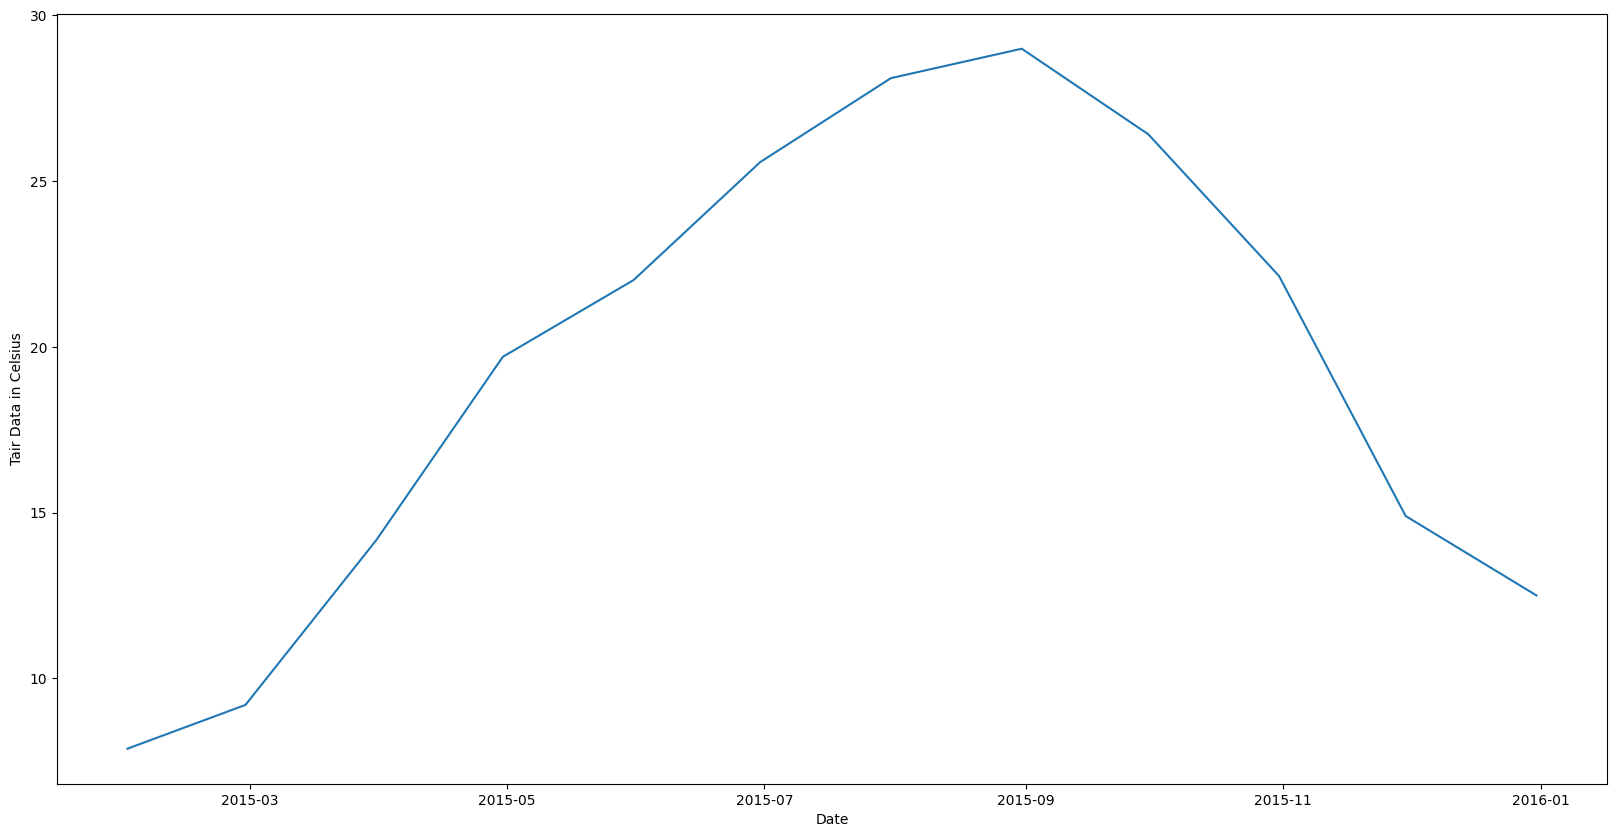

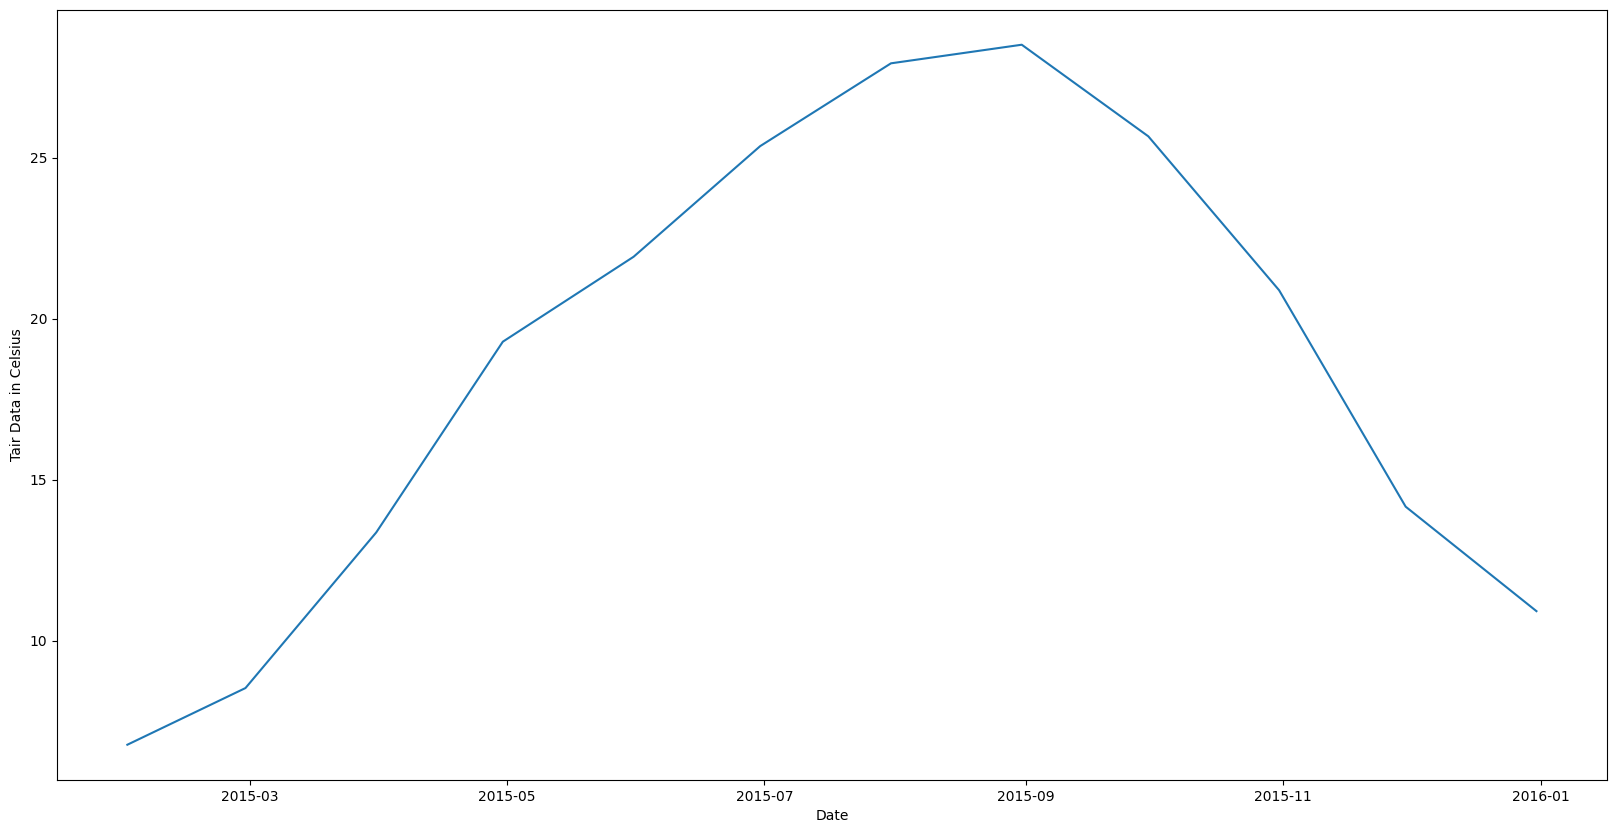

In [46]:
stations = [update_df_Tair.Station1, update_df_Tair.Station2, update_df_Tair.Station3, update_df_Tair.Station4, update_df_Tair.Station5, update_df_Tair.Station6]
# visualize station 1 data
for station in stations:
    fig, ax = plt.subplots()

    ax.plot(station)
    ax.set_xlabel('Date')
    ax.set_ylabel('Tair Data in Celsius')

    

In [48]:
# stationarity test for stations
for station in stations:
    ad_fuller_result = adfuller(station)

    print(f'ADF Statistic: {ad_fuller_result[0]}')
    print(f'p-value: {ad_fuller_result[1]}\n')

ADF Statistic: -3.2182985937943926
p-value: 0.018949619019006995

ADF Statistic: -3.6537053036894087
p-value: 0.004813513986163704

ADF Statistic: -3.4720411744924586
p-value: 0.00873484827074702

ADF Statistic: -1.4092584180175618
p-value: 0.5778295561149801

ADF Statistic: -3.1592988050434414
p-value: 0.022464846902750864

ADF Statistic: -3.5477015405653205
p-value: 0.0068432726270422324



In [47]:
train_list=[]
test_list=[]

# Train/Test Split
for station in stations:
    train_list.append(station[:'2015-10-17 23:00'])
    test_list.append(station['2015-10-17 23:00':])

In [52]:
# Defining optimize_SARIMAX function
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int)->pd.DataFrame:

    results=[]
    
    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(
            endog,
            exog,
            order=(order[0], d, order[1]),
            seasonal_order=(order[2], D, order[3], s),
            simple_differencing=False).fit(disp=False)
        except:
            continue
        
        results.append([order, model.aic])
    
    result_df=pd.DataFrame(results)
    result_df.columns = ['(p, q, P, Q)', 'AIC']
    
    # Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [53]:
# Define range of values for p, q, P, and Q

ps= range(0, 1, 1)
qs= range(0, 1, 1)
Ps= range(0, 1, 1)
Qs= range(0, 1, 1)

# Create list of all unique combinations
order_list = list(product(ps, qs, Ps, Qs))

# Set constants
d=0
D=0
s=12

In [54]:
SARIMA_result_df_list=[]

# Find the (p, d, q) (P, D, Q)m comination with the lowest AIC
for i, train in enumerate(train_list):
    SARIMA_result_df_list.append(optimize_SARIMAX(train, None, order_list, d, D, s))

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [116]:
optimal_parameters=[]
for station in SARIMA_result_df_list:
    result_array=station.to_numpy()
    optimal_parameters.append(result_array[0])
    print(result_array[0])

[(0, 0, 0, 0) 82.41682423607426]
[(0, 0, 0, 0) 82.62408554344037]
[(0, 0, 0, 0) 82.3775250588637]
[(0, 0, 0, 0) 82.6772512020166]
[(0, 0, 0, 0) 82.85635186216615]
[(0, 0, 0, 0) 82.5101721308063]


In [119]:
SARIMA_model_fit_array=[]
# Fit optimal model to study its residuals
for i, train in enumerate(train_list):
    SARIMA_model = SARIMAX(train, order=(result_array[0][0][0], 0, result_array[0][0][1]), seasonal_order = (result_array[0][0][2], 0, result_array[0][0][3], 12))
    SARIMA_model_fit_array.append(SARIMA_model.fit(disp=False))
    print(SARIMA_model_fit_array[i].summary())

                               SARIMAX Results                                
Dep. Variable:               Station1   No. Observations:                    9
Model:                        SARIMAX   Log Likelihood                 -40.208
Date:                Sun, 28 May 2023   AIC                             82.417
Time:                        15:18:28   BIC                             82.614
Sample:                    01-31-2015   HQIC                            81.991
                         - 09-30-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       444.6670    485.230      0.916      0.359    -506.367    1395.701
Ljung-Box (L1) (Q):                   6.62   Jarque-Bera (JB):                 0.98
Prob(Q):                              0.01   Pr

In [147]:
# Plot residual's diagnostics
for model in SARIMA_model_fit_array:
    model.plot_diagnostics(figsize=(10,8)) 

In [139]:
lbvalues = []
pvalues = []

# Run the Ljung-Box test
for model in SARIMA_model_fit_array:
    residuals = model.resid
    lbvalue, pvalue = acorr_ljungbox(residuals, np.arange(1, 3, 1))

    lbvalues.append(lbvalue)
    pvalues.append(pvalue)
    
    # Print p-values
    print(pvalue)


lb_pvalue
lb_pvalue
lb_pvalue
lb_pvalue
lb_pvalue
lb_pvalue


In [141]:
# Function to preform rolling forcasts
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:

    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'last_season':
        pred_last_season=[]
        
        for n, i in enumerate(range(train_len, total_len, window)):
            last_season = stations[n][i-window:i].values
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for n, i in enumerate(range(train_len, total_len, window)):
            model = SARIMAX(stations[n][:i], order=(VALUES), seasonal_order = (VALUES))
            res = model.fit(disp=False)
            predictions = res.get_predictions(0, i + window -1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMA.extend(oos_pred)
        
        return pred_SARIMA

In [142]:
pred_df_array=[]
for station in stations:
    pred_df_array.append(station['2015-12-31 23:00':])

In [146]:
# Define length of training set, horizon of forecast, and the window of forecast
TRAIN_LEN = 9
HORIZON = 3
WINDOW = 1



for i, station in enumerate(stations):
    # Preform rolling forecast with the naive seasonal baseline
    pred_df_array[i]['last_season'] = rolling_forecast(station, TRAIN_LEN, HORIZON, WINDOW, 'last_season')

#Display the predictions
print(pred_df_array)

[Date
last_season    [25.861444444444448, 20.934611559139785, 14.40...
Name: Station1, dtype: object, Date
last_season    [25.861444444444448, 20.934611559139785, 14.40...
Name: Station2, dtype: object, Date
last_season    [25.861444444444448, 20.934611559139785, 14.40...
Name: Station3, dtype: object, Date
last_season    [25.861444444444448, 20.934611559139785, 14.40...
Name: Station4, dtype: object, Date
last_season    [25.861444444444448, 20.934611559139785, 14.40...
Name: Station5, dtype: object, Date
last_season    [25.861444444444448, 20.934611559139785, 14.40...
Name: Station6, dtype: object]
